In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Thesis_DA-BCI/'
DATA_RAW   = DRIVE_PATH + 'data/raw/'
DATA_PROC  = DRIVE_PATH + 'data/processed/'
MODEL_PATH = DRIVE_PATH + 'results/models/'

os.makedirs(DATA_PROC, exist_ok=True)
os.makedirs(MODEL_PATH, exist_ok=True)

!pip install fooof mne -q

import tensorflow as tf
# tf.compat.v1.disable_eager_execution()

print("Setup complete.")
print(f"Raw files found: {len([f for f in os.listdir(DATA_RAW) if f.endswith('.mat')])}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.
Raw files found: 18


In [5]:
# =============================================================================
# DEBUG / DOCUMENTATION: Understand the raw .mat file structure
# =============================================================================
# This cell shows the internal structure of the original BCI Competition IV
# dataset files (AXXT.mat). It helps understand:
# - How many runs (cells) are in each file
# - Which runs contain labeled motor imagery trials
# - The shape of the raw EEG data (time x channels)

import scipy.io as sio
import numpy as np

mat = sio.loadmat(DATA_RAW + 'A01T.mat')
data = mat['data']

n_cells = data.shape[1]
print(f"Total cells (runs) in A01T.mat: {n_cells}\n")

for i in range(n_cells):
    cell = data[0, i][0, 0]          # numpy.void object
    X = cell['X']

    # Safe way to get 'y' (some cells have no labels)
    y = cell['y'].flatten() if 'y' in cell.dtype.names else np.array([])

    # Fixed: Convert shape tuple to string for clean printing
    x_shape_str = str(X.shape)

    print(f"Cell {i:2d}: X={x_shape_str:>12}, labeled={len(y)>0}")

Total cells (runs) in A01T.mat: 9

Cell  0: X= (29683, 25), labeled=False
Cell  1: X= (20172, 25), labeled=False
Cell  2: X= (41463, 25), labeled=False
Cell  3: X= (96735, 25), labeled=True
Cell  4: X= (96735, 25), labeled=True
Cell  5: X= (96735, 25), labeled=True
Cell  6: X= (96735, 25), labeled=True
Cell  7: X= (96735, 25), labeled=True
Cell  8: X= (96735, 25), labeled=True


In [6]:
# Global settings
channel_cnt   = 22
window_size   = 512
window_number = 44          # with step=20
fs            = 250
low, high     = 8, 30

learning_rate = 0.0001
total_epoch   = 50
batch_size_tr = 32
batch_size_val = window_number

# Default pair from paper (will be updated after source selection)
tgt = 1
src = 3

print("Global settings loaded.")

Global settings loaded.


In [7]:
import glob, os

DATA_PROC = '/content/drive/MyDrive/Thesis_DA-BCI/data/processed/'

old_files = glob.glob(DATA_PROC + 'A*TClass*.mat')

print(f"Found {len(old_files)} old Class files that would be deleted:")
for f in sorted(old_files):
    print("   ", os.path.basename(f))

# Uncomment the next two lines only when you really want to delete them
# for f in old_files:
#     os.remove(f)
# print("Old Class files deleted.")

files = [f for f in os.listdir(DATA_PROC) if 'Class' in f]
print(f"\nAfter cleanup, {len(files)} Class files remain.")

Found 36 old Class files that would be deleted:
    A01TClass1.mat
    A01TClass2.mat
    A01TClass3.mat
    A01TClass4.mat
    A02TClass1.mat
    A02TClass2.mat
    A02TClass3.mat
    A02TClass4.mat
    A03TClass1.mat
    A03TClass2.mat
    A03TClass3.mat
    A03TClass4.mat
    A04TClass1.mat
    A04TClass2.mat
    A04TClass3.mat
    A04TClass4.mat
    A05TClass1.mat
    A05TClass2.mat
    A05TClass3.mat
    A05TClass4.mat
    A06TClass1.mat
    A06TClass2.mat
    A06TClass3.mat
    A06TClass4.mat
    A07TClass1.mat
    A07TClass2.mat
    A07TClass3.mat
    A07TClass4.mat
    A08TClass1.mat
    A08TClass2.mat
    A08TClass3.mat
    A08TClass4.mat
    A09TClass1.mat
    A09TClass2.mat
    A09TClass3.mat
    A09TClass4.mat

After cleanup, 36 Class files remain.


In [9]:
# =============================================================================
# PREPROCESSING - Create per-class files (Improved with Skip + Delete Toggle)
# =============================================================================
import numpy as np
import scipy.io as sio
import mne
import gc
import os

# ── Settings ────────────────────────────────────────────────────────────────
DELETE_OLD_FILES = False   # ← Change to True only when you want to regenerate everything

N_CLASSES    = 4
EEG_CHANNELS = 22
TRIAL_LENGTH = 1875
SFREQ        = 250
LOW_FREQ     = 8
HIGH_FREQ    = 30
BASELINE_END = 250
CROP_START   = 500
OUTPUT_LEN   = TRIAL_LENGTH - CROP_START

raw_path  = DATA_RAW
data_path = DATA_PROC


def preprocess_trial(trial):
    """Baseline correction → Bandpass → Crop"""
    # 1. Baseline correction on raw signal
    baseline = np.mean(trial[:, :BASELINE_END], axis=1, keepdims=True)
    trial = trial - baseline

    # 2. Bandpass filter
    filtered = mne.filter.filter_data(
        trial.astype(np.float64),
        sfreq=SFREQ,
        l_freq=LOW_FREQ,
        h_freq=HIGH_FREQ,
        verbose=False
    )

    # 3. Crop
    return filtered[:, CROP_START:].astype(np.float32)


def extract_and_preprocess(X, trial_starts, labels):
    n_trials = len(trial_starts)
    trials = np.zeros((n_trials, EEG_CHANNELS, OUTPUT_LEN), dtype=np.float32)

    for i, start in enumerate(trial_starts):
        end = start + TRIAL_LENGTH
        if end <= X.shape[0]:
            raw_trial = X[start:end, :EEG_CHANNELS].T
        else:
            raw_trial = np.zeros((EEG_CHANNELS, TRIAL_LENGTH), dtype=np.float32)
            available = X.shape[0] - start
            raw_trial[:, :available] = X[start:, :EEG_CHANNELS].T

        trials[i] = preprocess_trial(raw_trial)

    return trials, np.array(labels)


def split_subject(sbj):
    """Process one subject with skip logic"""
    out_files = [os.path.join(data_path, f'A{sbj:02d}TClass{cls}.mat')
                 for cls in range(1, N_CLASSES+1)]

    # Check if all files already exist
    if all(os.path.exists(f) for f in out_files) and not DELETE_OLD_FILES:
        print(f"Subject {sbj:2d} → Already processed (skipped)")
        return

    # Delete old files if toggle is True
    if DELETE_OLD_FILES:
        for f in out_files:
            if os.path.exists(f):
                os.remove(f)
                print(f"  Deleted old: A{sbj:02d}TClass{cls}.mat")

    # ── Actual Processing ───────────────────────────────────────────────────
    mat_path = os.path.join(raw_path, f'A{sbj:02d}T.mat')
    print(f'\nProcessing Subject {sbj}: {mat_path}')

    mat = sio.loadmat(mat_path)
    data = mat['data']

    n_cells = data.shape[1]
    mi_runs = [i for i in range(n_cells) if data[0, i][0, 0]['y'].flatten().size > 0]
    print(f'  Labeled runs: {mi_runs}')

    all_trials, all_labels = [], []

    for run_idx in mi_runs:
        cell = data[0, run_idx][0, 0]
        X = cell['X']
        trial_starts = cell['trial'].flatten() - 1
        labels = cell['y'].flatten()

        trials, y = extract_and_preprocess(X, trial_starts, labels)
        all_trials.append(trials)
        all_labels.append(y)
        print(f'  Run {run_idx}: {trials.shape[0]} trials preprocessed')

    all_trials = np.concatenate(all_trials, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    print(f'  Total: {all_trials.shape} | Class distribution: '
          f'{ {c: int(np.sum(all_labels==c)) for c in range(1,5)} }')

    # Save per class
    for cls in range(1, N_CLASSES + 1):
        idx = np.where(all_labels == cls)[0]
        class_data = np.transpose(all_trials[idx], (1, 2, 0))   # (22, 1375, 72)
        out_path = os.path.join(data_path, f'A{sbj:02d}TClass{cls}.mat')
        sio.savemat(out_path, {f'Class{cls}': class_data})
        print(f'  Class {cls}: {class_data.shape} → saved')

    del all_trials, all_labels
    gc.collect()


# ── Run for all subjects ────────────────────────────────────────────────────
print(f"DELETE_OLD_FILES = {DELETE_OLD_FILES}\n")

for sbj in range(1, 10):
    split_subject(sbj)

print("\n=== Preprocessing Complete! ===")

# Quick verification
for sbj in [1, 5, 9]:
    mat = sio.loadmat(data_path + f'A{sbj:02d}TClass1.mat')
    print(f'Subject {sbj} Class1 shape: {mat["Class1"].shape}')

DELETE_OLD_FILES = False

Subject  1 → Already processed (skipped)
Subject  2 → Already processed (skipped)
Subject  3 → Already processed (skipped)
Subject  4 → Already processed (skipped)
Subject  5 → Already processed (skipped)
Subject  6 → Already processed (skipped)
Subject  7 → Already processed (skipped)
Subject  8 → Already processed (skipped)
Subject  9 → Already processed (skipped)

=== Preprocessing Complete! ===
Subject 1 Class1 shape: (22, 1375, 72)
Subject 5 Class1 shape: (22, 1375, 72)
Subject 9 Class1 shape: (22, 1375, 72)


In [ ]:
# =============================================================================
# DEBUG: Check GPU availability
# =============================================================================
import torch
import subprocess

print("PyTorch CUDA available:", torch.cuda.is_available())

# Optional: Show GPU details
try:
    result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
    print(result.stdout[:500])   # first 500 characters only
except FileNotFoundError:
    print("nvidia-smi command not found (not running on GPU machine)")

PyTorch CUDA available: True
Thu Apr 16 13:02:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       


In [ ]:
# Memory Calculator for Sliding Windows (Diagnostic)
# Uncomment to run when you want to check memory usage

# window_size    = 512
# trial_len      = 1374
# n_trials_train = 50
# n_trials_val   = 22
# n_classes      = 4
# n_subjects     = 9
# bytes_per_window = 22 * 512 * 4   # float32

# print(f"{'Step':>6} {'Windows/trial':>14} {'Total GB':>10} {'Fits in RAM?':>14}")
# print("-" * 55)
# for step in [1, 5, 10, 15, 20, 25, 30]:
#     n_windows = (trial_len - window_size) // step + 1
#     total_train = n_windows * n_trials_train * n_classes * n_subjects
#     total_val   = n_windows * n_trials_val   * n_classes * n_subjects
#     total_gb    = (total_train + total_val) * bytes_per_window / (1024**3)
#     fits        = "✓ Yes" if total_gb < 12 else "✗ Too big"
#     print(f"{step:>6} {n_windows:>14} {total_gb:>10.2f} GB {fits:>14}")

  Step  Windows/trial   Total GB   Fits in RAM?
-------------------------------------------------------
     1            863      93.86 GB      ✗ Too big
     5            173      18.82 GB      ✗ Too big
    10             87       9.46 GB          ✓ Yes
    15             58       6.31 GB          ✓ Yes
    20             44       4.79 GB          ✓ Yes
    25             35       3.81 GB          ✓ Yes
    30             29       3.15 GB          ✓ Yes


In [10]:
# =============================================================================
# SLIDING WINDOW AUGMENTATION (Memory-efficient & closer to paper)
# =============================================================================
import numpy as np
import scipy.io as sio
import gc, os
from joblib import Parallel, delayed

# ── Constants ────────────────────────────────────────────────────────────────
WINDOW_SIZE = window_size
CHANNEL_CNT = channel_cnt
N_CLASSES   = 4
TRIAL_LEN   = 1374
STEP        = 20                    # Paper uses 1; we use 20 to fit in RAM
N_WINDOWS   = (TRIAL_LEN - WINDOW_SIZE) // STEP + 1

val_idx = list(range(0, 22))
tr_idx  = list(range(22, 72))

print("Sliding Window Settings:")
print(f"  Window size     : {WINDOW_SIZE} samples ({WINDOW_SIZE/250:.2f} s)")
print(f"  Step size       : {STEP} samples")
print(f"  Windows per trial: {N_WINDOWS}")
print(f"  Train trials/class: {len(tr_idx)} | Val trials/class: {len(val_idx)}\n")

# ── Toggle: Delete old files before regenerating ─────────────────────────────
DELETE_OLD_FILES = False   # Set True only when you want to regenerate everything

if DELETE_OLD_FILES:
    print("Deleting old Rolled_ files...")
    count = 0
    for f in os.listdir(data_path):
        if f.startswith('Rolled_'):
            os.remove(os.path.join(data_path, f))
            print(f"   Deleted: {f}")
            count += 1
    print(f"Deleted {count} old files.\n")


def load_subject(sb):
    """Load the 4 class files for one subject."""
    data = []
    for cls in range(1, N_CLASSES + 1):
        mat = sio.loadmat(data_path + f'A{sb:02d}TClass{cls}.mat')[f'Class{cls}']
        data.append(mat)
    return data


def roll_and_save(sb, split, class_indices):
    """Create sliding windows and save as memory-mapped files (stable on Drive)."""
    data = load_subject(sb)
    n_trials_per_cls = len(class_indices)
    total_windows = N_CLASSES * n_trials_per_cls * N_WINDOWS

    dat_path = data_path + f'Rolled_{split}dat_{sb}.npy'
    lbl_path = data_path + f'Rolled_{split}lbl_{sb}.npy'

    # Remove any leftover files
    for p in [dat_path, lbl_path]:
        if os.path.exists(p):
            os.remove(p)

    # Memory-mapped files (avoids loading everything into RAM)
    dat_mm = np.lib.format.open_memmap(dat_path, mode='w+', dtype=np.float32,
                                       shape=(total_windows, CHANNEL_CNT, WINDOW_SIZE, 1))
    lbl_mm = np.lib.format.open_memmap(lbl_path, mode='w+', dtype=np.uint8,
                                       shape=(total_windows,))

    write_idx = 0
    for cls_label, cur_dat in enumerate(data):
        trials = cur_dat[:, :, class_indices]          # (22, 1374, n_trials)
        for t in range(trials.shape[2]):
            trial = trials[:, :TRIAL_LEN, t]
            for w in range(0, TRIAL_LEN - WINDOW_SIZE + 1, STEP):
                dat_mm[write_idx, :, :, 0] = trial[:, w:w + WINDOW_SIZE]
                lbl_mm[write_idx] = cls_label
                write_idx += 1
        print(f"  Subject {sb:2d} - Class {cls_label+1}/4 done")
        gc.collect()

    dat_mm.flush()
    lbl_mm.flush()
    del dat_mm, lbl_mm, data
    gc.collect()
    print(f"  Subject {sb:2d} → Saved {split} split: {write_idx} windows")


# ── Main: Run sequentially (safer with Google Drive) ────────────────────────
print("Starting sliding window creation...\n")

for sb in range(1, 10):
    print(f"=== Subject {sb}/9 ===")
    roll_and_save(sb, 'T', tr_idx)
    roll_and_save(sb, 'V', val_idx)

print("\nSliding window augmentation completed successfully!")
print("All Rolled_ files are ready.")

Sliding Window Settings:
  Window size     : 512 samples (2.05 s)
  Step size       : 20 samples
  Windows per trial: 44
  Train trials/class: 50 | Val trials/class: 22

Starting sliding window creation...

=== Subject 1/9 ===
  Subject  1 - Class 1/4 done
  Subject  1 - Class 2/4 done
  Subject  1 - Class 3/4 done
  Subject  1 - Class 4/4 done
  Subject  1 → Saved T split: 8800 windows
  Subject  1 - Class 1/4 done
  Subject  1 - Class 2/4 done
  Subject  1 - Class 3/4 done
  Subject  1 - Class 4/4 done
  Subject  1 → Saved V split: 3872 windows
=== Subject 2/9 ===
  Subject  2 - Class 1/4 done
  Subject  2 - Class 2/4 done
  Subject  2 - Class 3/4 done
  Subject  2 - Class 4/4 done
  Subject  2 → Saved T split: 8800 windows
  Subject  2 - Class 1/4 done
  Subject  2 - Class 2/4 done
  Subject  2 - Class 3/4 done
  Subject  2 - Class 4/4 done
  Subject  2 → Saved V split: 3872 windows
=== Subject 3/9 ===
  Subject  3 - Class 1/4 done
  Subject  3 - Class 2/4 done
  Subject  3 - Class 

In [11]:
# VERIFY ALL ROLLED WINDOW FILES
print("Verifying all Rolled_ files...")

missing = []
for sbj in range(1, 10):
    for split in ['T', 'V']:
        for kind in ['dat', 'lbl']:
            p = data_path + f'Rolled_{split}{kind}_{sbj}.npy'
            if os.path.exists(p):
                size_mb = os.path.getsize(p) / (1024 * 1024)
                print(f"  ✓ Rolled_{split}{kind}_{sbj}.npy ({size_mb:.1f} MB)")
            else:
                print(f"  ✗ MISSING: Rolled_{split}{kind}_{sbj}.npy")
                missing.append(p)

print(f"\nTotal files expected: 36")
print(f"Missing files: {len(missing)}")

if not missing:
    print("All files present — ready for source selection and training!")
else:
    print(f"{len(missing)} files missing — rerun the sliding window cell.")

Verifying all Rolled_ files...
  ✓ Rolled_Tdat_1.npy (378.1 MB)
  ✓ Rolled_Tlbl_1.npy (0.0 MB)
  ✓ Rolled_Vdat_1.npy (166.4 MB)
  ✓ Rolled_Vlbl_1.npy (0.0 MB)
  ✓ Rolled_Tdat_2.npy (378.1 MB)
  ✓ Rolled_Tlbl_2.npy (0.0 MB)
  ✓ Rolled_Vdat_2.npy (166.4 MB)
  ✓ Rolled_Vlbl_2.npy (0.0 MB)
  ✓ Rolled_Tdat_3.npy (378.1 MB)
  ✓ Rolled_Tlbl_3.npy (0.0 MB)
  ✓ Rolled_Vdat_3.npy (166.4 MB)
  ✓ Rolled_Vlbl_3.npy (0.0 MB)
  ✓ Rolled_Tdat_4.npy (378.1 MB)
  ✓ Rolled_Tlbl_4.npy (0.0 MB)
  ✓ Rolled_Vdat_4.npy (166.4 MB)
  ✓ Rolled_Vlbl_4.npy (0.0 MB)
  ✓ Rolled_Tdat_5.npy (378.1 MB)
  ✓ Rolled_Tlbl_5.npy (0.0 MB)
  ✓ Rolled_Vdat_5.npy (166.4 MB)
  ✓ Rolled_Vlbl_5.npy (0.0 MB)
  ✓ Rolled_Tdat_6.npy (378.1 MB)
  ✓ Rolled_Tlbl_6.npy (0.0 MB)
  ✓ Rolled_Vdat_6.npy (166.4 MB)
  ✓ Rolled_Vlbl_6.npy (0.0 MB)
  ✓ Rolled_Tdat_7.npy (378.1 MB)
  ✓ Rolled_Tlbl_7.npy (0.0 MB)
  ✓ Rolled_Vdat_7.npy (166.4 MB)
  ✓ Rolled_Vlbl_7.npy (0.0 MB)
  ✓ Rolled_Tdat_8.npy (378.1 MB)
  ✓ Rolled_Tlbl_8.npy (0.0 MB)
  ✓ Rolle

In [12]:
!pip install specparam -q

SOURCE SELECTION — PAPER-MATCHING RESTING-STATE EXTRACTION

Step 1: Extracting raw 1s resting-state as in the paper...
   Processing subject 1/9 ...
   Processing subject 2/9 ...
   Processing subject 3/9 ...
   Processing subject 4/9 ...
   Processing subject 5/9 ...
   Processing subject 6/9 ...
   Processing subject 7/9 ...
   Processing subject 8/9 ...
   Processing subject 9/9 ...

All PSDs shape: (9, 22, 126)

Step 2: Fitting SpecParam...

Step 3: Building feature vectors...

Step 4: Computing cosine distance matrix...
Distance matrix (rounded):
     S01  S02  S03  S04  S05  S06  S07  S08  S09
S01  0.000  0.044  0.135  0.045  0.038  0.082  0.038  0.120  0.331
S02  0.044  0.000  0.140  0.050  0.046  0.071  0.034  0.072  0.315
S03  0.135  0.140  0.000  0.163  0.196  0.125  0.136  0.120  0.213
S04  0.045  0.050  0.163  0.000  0.041  0.119  0.026  0.146  0.368
S05  0.038  0.046  0.196  0.041  0.000  0.106  0.022  0.121  0.326
S06  0.082  0.071  0.125  0.119  0.106  0.000  0.090  0.07

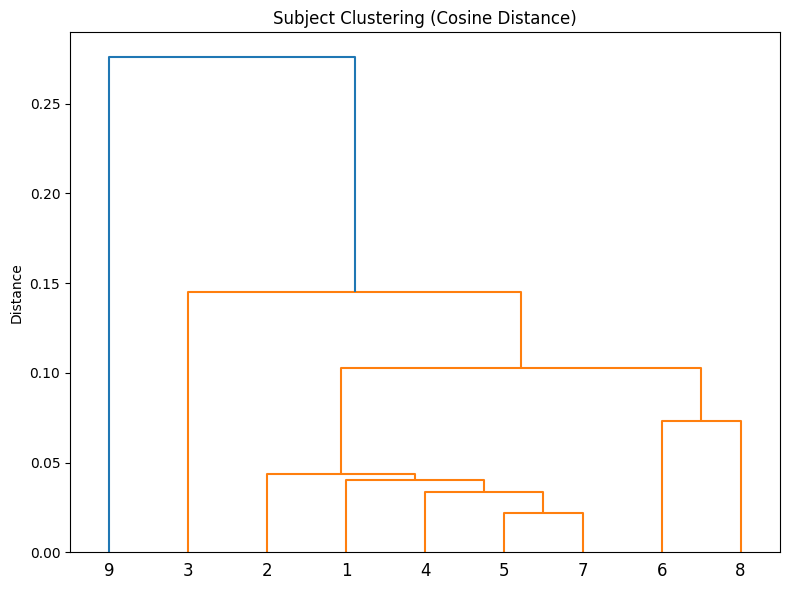

Source selection complete!


In [13]:
# =============================================================================
# SOURCE SELECTION — PAPER-MATCHING RESTING-STATE EXTRACTION
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
# import scipy.io as sio
import scipy.signal as signal
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import cosine
from specparam import SpectralModel
from joblib import Parallel, delayed
import warnings
import os

warnings.filterwarnings('ignore')

raw_path    = DRIVE_PATH + 'data/raw/'
RESULTS_DIR = DRIVE_PATH + 'results/source_selection/'
os.makedirs(RESULTS_DIR, exist_ok=True)

N_SUBJECTS   = 9
N_CHANNELS   = 22
SFREQ        = 250
LOW_FREQ     = 8
HIGH_FREQ    = 30
BASELINE_PTS = 250   # 1 second resting period
N_FFT        = 250

print("=" * 70)
print("SOURCE SELECTION — PAPER-MATCHING RESTING-STATE EXTRACTION")
print("=" * 70)

# ── Step 1: Extract raw resting-state (NO baseline correction) ─────────────
print("\nStep 1: Extracting raw 1s resting-state as in the paper...")

b, a = signal.butter(4, [LOW_FREQ, HIGH_FREQ], btype='band', fs=SFREQ)

def compute_subject_psd(sbj):
    """Load raw .mat, extract raw 1s resting period, bandpass only, compute PSD"""
    mat = sio.loadmat(raw_path + f'A{sbj:02d}T.mat')
    data = mat['data']
    mi_runs = [i for i in range(data.shape[1]) if data[0, i][0, 0]['y'].flatten().size > 0]

    all_resting = []
    for run_idx in mi_runs:
        cell = data[0, run_idx][0, 0]
        X = cell['X'][:, :N_CHANNELS]                    # raw data
        trial_starts = cell['trial'].flatten() - 1

        for start in trial_starts:
            # Take RAW 1-second fixation period — NO baseline subtraction
            resting = X[start:start + BASELINE_PTS, :].T   # shape (22, 250)
            all_resting.append(resting)

    all_resting = np.array(all_resting, dtype=np.float32)

    # Only bandpass filter (no baseline correction)
    filtered = np.zeros_like(all_resting, dtype=np.float64)
    for ch in range(N_CHANNELS):
        for t in range(len(all_resting)):
            filtered[t, ch] = signal.filtfilt(b, a, all_resting[t, ch])

    # Welch PSD
    psds = []
    freqs_out = None
    for t in range(filtered.shape[0]):
        trial_psds = []
        for ch in range(N_CHANNELS):
            f, p = signal.welch(filtered[t, ch], fs=SFREQ,
                                nperseg=N_FFT, noverlap=N_FFT//2)
            trial_psds.append(p)
            if freqs_out is None:
                freqs_out = f
        psds.append(trial_psds)

    mean_psd = np.mean(np.array(psds), axis=0)
    return mean_psd, freqs_out


all_psds = []
freqs = None
for sbj in range(1, 10):
    print(f"   Processing subject {sbj}/9 ...")
    psd, f = compute_subject_psd(sbj)
    if freqs is None:
        freqs = f
    all_psds.append(psd)
all_psds = np.array(all_psds)

print(f"\nAll PSDs shape: {all_psds.shape}")

# ── Step 2: SpecParam ───────────────────────────────────────────────────────
print("\nStep 2: Fitting SpecParam...")

freq_mask = (freqs >= LOW_FREQ) & (freqs <= HIGH_FREQ)
n_freqs_sel = np.sum(freq_mask)

def fit_one_channel(sbj_idx, ch_idx, psd_full):
    try:
        fm = SpectralModel(
            peak_width_limits=[0.5, 12.0],
            max_n_peaks=5,
            min_peak_height=0.0,
            peak_threshold=2.0,
            aperiodic_mode='fixed',
            verbose=False
        )
        fm.fit(freqs, psd_full, [LOW_FREQ, HIGH_FREQ])
        return sbj_idx, ch_idx, fm.fooofed_spectrum_, fm._ap_fit
    except:
        raw = psd_full[freq_mask]
        return sbj_idx, ch_idx, raw, np.zeros(n_freqs_sel)


jobs = [(sbj, ch, all_psds[sbj, ch]) for sbj in range(9) for ch in range(22)]
results = Parallel(n_jobs=-1, prefer='processes', timeout=20)(
    delayed(fit_one_channel)(*job) for job in jobs
)

corrected = np.zeros((9, 22, n_freqs_sel))
background = np.zeros((9, 22, n_freqs_sel))
for s, c, fooofed, bg in results:
    corrected[s, c] = fooofed
    background[s, c] = bg

final = corrected - background

# ── Steps 3-6: Distance, selection, dendrogram ──────────────────────────────
print("\nStep 3: Building feature vectors...")
feature_vectors = final.reshape(9, -1)

print("\nStep 4: Computing cosine distance matrix...")
dist_matrix = np.zeros((9, 9))
for i in range(9):
    for j in range(9):
        dist_matrix[i, j] = cosine(feature_vectors[i], feature_vectors[j])

print("Distance matrix (rounded):")
header = "     " + "  ".join([f"S{i+1:02d}" for i in range(9)])
print(header)
for i in range(9):
    row = f"S{i+1:02d}  " + "  ".join([f"{dist_matrix[i,j]:.3f}" for j in range(9)])
    print(row)

print("\nSelected sources:")
print(f"{'Target':>8} {'Source':>8} {'Distance':>10}")
print("-" * 30)
source_pairs = {}
for t in range(9):
    d = dist_matrix[t].copy()
    d[t] = np.inf
    src = np.argmin(d)
    dist = d[src]
    source_pairs[t+1] = (src+1, dist)
    print(f"{t+1:>8} {src+1:>8} {dist:>10.4f}")

paper_pairs = {1:3, 2:4, 3:1, 4:2, 5:4, 6:3, 7:9, 8:9, 9:8}
print("\nComparison with Paper Table I:")
print(f"{'Target':>8} {'Our Src':>8} {'Paper Src':>8} {'Match':>8}")
matches = 0
for t in range(1,10):
    our = source_pairs[t][0]
    p = paper_pairs[t]
    m = "✓" if our == p else "✗"
    if m == "✓": matches += 1
    print(f"{t:>8} {our:>8} {p:>8} {m:>8}")
print(f"\nMatches: {matches}/9")

# Dendrogram
print("\nPlotting clustering...")
link = linkage(feature_vectors, method="average", metric="cosine")
plt.figure(figsize=(8,6))
plt.title("Subject Clustering (Cosine Distance)")
plt.ylabel("Distance")
dendrogram(link, labels=[str(i) for i in range(1,10)])
plt.tight_layout()
plt.savefig(RESULTS_DIR + 'clustering_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

print("Source selection complete!")

In [14]:
# =============================================================================
# DEBUG: Check which version of compute_subject_psd is currently loaded
# =============================================================================
import inspect

try:
    source = inspect.getsource(compute_subject_psd)
    print("compute_subject_psd function source (first 300 chars):")
    print(source[:300])
except NameError:
    print("Error: compute_subject_psd is not defined yet.")
    print("Make sure you have run the source selection cell first.")

compute_subject_psd function source (first 300 chars):
def compute_subject_psd(sbj):
    """Load raw .mat, extract raw 1s resting period, bandpass only, compute PSD"""
    mat = sio.loadmat(raw_path + f'A{sbj:02d}T.mat')
    data = mat['data']
    mi_runs = [i for i in range(data.shape[1]) if data[0, i][0, 0]['y'].flatten().size > 0]

    all_resting = 


In [17]:
# =============================================================================
# IMPROVED DOMAIN ADAPTATION TRAINING - Fixed Version
# =============================================================================
import tensorflow as tf
from tensorflow.keras import layers, Model, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback
import numpy as np

# =============================================================================
# Make sure src and tgt are set here (you can change them)
# =============================================================================
# Change these two lines according to your source selection results
src = 8      # ← Change this
tgt = 9      # ← Change this

print(f"Training: Source Subject {src} → Target Subject {tgt}")

# Load data
src_dat, src_lbl = load_rolled(src, 'T')
tgt_val_dat, tgt_val_lbl = load_rolled(tgt, 'V')

# Per-channel Z-score normalization (very important)
def normalize_data(data):
    mean = np.mean(data, axis=(0, 2, 3), keepdims=True)
    std  = np.std(data, axis=(0, 2, 3), keepdims=True) + 1e-8
    return (data - mean) / std

src_dat = normalize_data(src_dat)
tgt_val_dat = normalize_data(tgt_val_dat)

print(f"Source train: {src_dat.shape} | Target val: {tgt_val_dat.shape}")

src_lbl_cat = tf.keras.utils.to_categorical(src_lbl, 4)
tgt_val_lbl_cat = tf.keras.utils.to_categorical(tgt_val_lbl, 4)

# Gradient Reversal Layer
class GradientReversalLayer(layers.Layer):
    def __init__(self, lambda_val=0.1):
        super().__init__()
        self.lambda_val = tf.Variable(lambda_val, trainable=False, dtype=tf.float32)

    def call(self, x):
        return tf.stop_gradient(x) * (-self.lambda_val) + x   # reversed gradient

# Build Model
def build_da_model(initial_lambda=0.1):
    inputs = layers.Input(shape=(22, 512, 1))

    x = layers.Conv2D(16, (1, 64), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4), activation='elu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((1, 2))(x)
    x = layers.Dropout(0.65)(x)

    x = layers.Conv2D(32, (1, 32), padding='same',
                      kernel_regularizer=regularizers.l2(1e-4), activation='elu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((1, 2))(x)
    x = layers.Dropout(0.65)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='elu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.65)(x)

    label_out = layers.Dense(4, activation='softmax', name='label')(x)

    # Domain branch
    domain_x = GradientReversalLayer(initial_lambda)(x)
    domain_out = layers.Dense(2, activation='softmax', name='domain')(domain_x)

    model = Model(inputs, [label_out, domain_out])
    return model

model = build_da_model(initial_lambda=0.1)

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss={'label': 'categorical_crossentropy', 'domain': 'categorical_crossentropy'},
    loss_weights={'label': 1.0, 'domain': 0.1},
    metrics={'label': 'accuracy', 'domain': 'accuracy'}
)

# Custom Callback for Lambda Scheduling
class LambdaScheduler(Callback):
    def __init__(self, max_lambda=1.0):
        super().__init__()
        self.max_lambda = max_lambda

    def on_epoch_end(self, epoch, logs=None):
        current_lambda = 0.1 + (self.max_lambda - 0.1) * (epoch / 24)
        # Update GradientReversalLayer lambda
        for layer in self.model.layers:
            if isinstance(layer, GradientReversalLayer):
                layer.lambda_val.assign(current_lambda)
                break
        print(f"  → Lambda updated to {current_lambda:.3f}")

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_label_accuracy', patience=8, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_label_accuracy', factor=0.5, patience=4,
                      mode='max', verbose=1),
    LambdaScheduler(max_lambda=1.0)
]

print("\nStarting training...\n")

history = model.fit(
    src_dat,
    {'label': src_lbl_cat, 'domain': np.zeros((len(src_dat), 2))},   # source = 0
    validation_data=(
        tgt_val_dat,
        {'label': tgt_val_lbl_cat, 'domain': np.ones((len(tgt_val_dat), 2))}  # target = 1
    ),
    batch_size=64,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

# Save model
model.save(MODEL_PATH + f'da_model_src{src}_tgt{tgt}.keras')
print(f"\nTraining finished! Model saved as da_model_src{src}_tgt{tgt}.keras")

Training: Source Subject 8 → Target Subject 9
Source train: (8800, 22, 512, 1) | Target val: (3872, 22, 512, 1)

Starting training...

Epoch 1/30
138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - domain_accuracy: 0.5143 - domain_loss: 0.0000e+00 - label_accuracy: 0.2586 - label_loss: 3.3615 - loss: 3.3897  → Lambda updated to 0.100
138/138 ━━━━━━━━━━━━━━━━━━━━ 26s 97ms/step - domain_accuracy: 0.5232 - domain_loss: 0.0000e+00 - label_accuracy: 0.2733 - label_loss: 2.9267 - loss: 2.9557 - val_domain_accuracy: 0.0480 - val_domain_loss: 3.3653 - val_label_accuracy: 0.2412 - val_label_loss: 2.3226 - val_loss: 2.7003 - learning_rate: 1.0000e-04
Epoch 2/30
137/138 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - domain_accuracy: 0.5186 - domain_loss: 0.0000e+00 - label_accuracy: 0.2933 - label_loss: 2.7792 - loss: 2.8079  → Lambda updated to 0.138
138/138 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - domain_accuracy: 0.4977 - domain_loss: 0.0000e+00 - label_accuracy: 0.3000 - label_loss: 2.9196 - loss: 2.9438 - val_doma